In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
#Variables

#Value of gravitational acceleration
g = 1

#Length and mass of the top rod
l1 = 1
m1 = 1
#Length and mass of the second rod
l2 = l1
m2 = 1

In [3]:
#Class for double pendulum

class Double_Pendulum : 
    def __init__(self, t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0) : 
        self.t1 = t1
        self.g = g
        self.l1 = l1
        self.l2 = l2
        self.m1 = m1
        self.m2 = m2
        self.theta1_0 = theta1_0
        self.v1_0 = v1_0
        self.theta2_0 = theta2_0
        self.v2_0 = v2_0
    
    def RK4(self, v2_0, theta2_0, h):
    
        #Initialise the arrays to be used
        # t is an array containing each of the timepoints that we will step forward to
        t = np.arange(0,t1+h,h)
        # n is the number of timesteps in t
        n = np.shape(t)[0]
        # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
        theta1 = np.zeros(n)
        theta2 = np.zeros(n)
        #same for velocities
        v1 = np.zeros(n)
        v2 = np.zeros(n)
    
        M = m1+m2
    
        #Set the initial value of x and v
        theta1[0] = theta1_0
        v1[0] = v1_0
        theta2[0] = theta2_0
        v2[0] = v2_0
    
        #define F(theta) for coupled equation 1
        def F1(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
        #Define G(v) for coupled equation 1
        def G1(v1):
        
            return v1
    
        #define F(theta) for coupled equation 2
        def F2(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
        #Define G(v) for coupled equation 2
        def G2(v2):
        
            return v2
    
    
        #Loop over the time values and calculate the derivatives
        for i in range(1,n): 
            # Calculate the Runge - Kutta intermediate values for both formulas
            f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
            f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
            f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
            g1 = h * G1(v1[i-1])
            g2 = h * G1(v1[i-1]+g1/2)
            g3 = h * G1(v1[i-1]+g2/2)
            g4 = h * G1(v1[i-1]+g3)
        
            e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
            e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
            e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
            j1 = h * G2(v2[i-1])
            j2 = h * G2(v2[i-1]+j1/2)
            j3 = h * G2(v2[i-1]+j2/2)
            j4 = h * G2(v2[i-1]+j3)
        
            theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
            v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
            theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
            v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
        
        
        return(t,theta1,theta2,v1,v2)
    
    
    def PoincareFull(self, N,title="Default Title"):
        
        #Setting Size for the figure
        plt.figure(figsize=(15,10))
        
        #Setting an initial value for initial theta2 that will be used to create subsequent theta2 intitial values
        theta2_0_ = self.theta2_0
        M = m1+m2
        
        #An array to store values of potential energy using N to determine how many loops it does
        E = np.zeros(N+1)
        
        #Setting an initial energy for the first state of the system
        E[0] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
        for i in range(1, len(E)):
            print(i)
            
            #Setting a new initial theta2
            theta2_0 = i*theta2_0_
            
            #Setting a new potential energy using the new theta2
            
            E[i] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
            
            #Finding the difference between the new potential energy and the initial one to find the amount of kinetic energy to give the system
            EDiff = E[i]-E[0]
            
            #Setting an initial v2 using the kinetic energy
            v2_0 = (-m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0)  +  np.sqrt( (m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0))**2 - 2*m2*(l2**2) * (1/2*m1*((l1*v1_0)**2) + 1/2*m2*(l1**2)*(v1_0**2) - EDiff )  ) ) / (m2*(l2)**2)
            
            t,theta1,theta2,v1,v2 = self.RK4(v2_0, theta2_0, h)
            
            crossTheta2 = np.array([])
            crossV2 = np.array([])
        
            for i in range(len(theta1)-1):
                #Test to see if theta1 crosses 0
                if theta1[i] <= 0 and theta1[i+1] >= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif theta1[i] >= 0 and theta1[i+1] <= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])

                elif np.abs(theta1[i]) <= 0.1 and abs(theta1[i+1]) >= 2*np.pi-0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif np.abs(theta1[i]) >= 2*np.pi-0.1 and abs(theta1[i+1]) <= 0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                    
            plt.scatter(crossTheta2, crossV2, label="Initial Theta 2 = "+ str(np.round(theta2_0, 3)))
            
            
        plt.title(title, fontsize=20)
        plt.xlabel("Theta 2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.legend(bbox_to_anchor=(1.3, 1), fontsize=15)
        plt.show()
        
        return 0
    
    def Poincare(self, title="Default Title"):
        crossTheta2 = np.array([])
        crossV2 = np.array([])
        t,theta1,theta2,v1,v2 = self.RK4(theta2_0, v2_0, h)
        
        for i in range(len(theta1)-1):
                #Test to see if theta1 crosses 0
            if theta1[i] <= 0 and theta1[i+1] >= 0:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])
            elif theta1[i] >= 0 and theta1[i+1] <= 0:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])

            elif np.abs(theta1[i]) <= 0.1 and abs(theta1[i+1]) >= 2*np.pi-0.1:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])
            elif np.abs(theta1[i]) >= 2*np.pi-0.1 and abs(theta1[i+1]) <= 0.1:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])

        plt.scatter(crossTheta2, crossV2, alpha=0.7)    
        plt.title(title, fontsize=20)
        plt.xlabel("Theta 2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.savefig('poincare_one2oneL.png', dpi=300) 
        plt.show()
        
        return 0
    
print('hi')

hi


In [4]:
#More Class

class Double_Pendulum : 
    def __init__(self, t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0) : 
        self.t1 = t1
        self.g = g
        self.l1 = l1
        self.l2 = l2
        self.m1 = m1
        self.m2 = m2
        self.theta1_0 = theta1_0
        self.v1_0 = v1_0
        self.theta2_0 = theta2_0
        self.v2_0 = v2_0
    
    def RK4(self, v2_0, theta2_0, h):
    
        #Initialise the arrays to be used
        # t is an array containing each of the timepoints that we will step forward to
        t = np.arange(0,t1+h,h)
        # n is the number of timesteps in t
        n = np.shape(t)[0]
        # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
        theta1 = np.zeros(n)
        theta2 = np.zeros(n)
        #same for velocities
        v1 = np.zeros(n)
        v2 = np.zeros(n)
    
        M = m1+m2
    
        #Set the initial value of x and v
        theta1[0] = theta1_0
        v1[0] = v1_0
        theta2[0] = theta2_0
        v2[0] = v2_0
    
        #define F(theta) for coupled equation 1
        def F1(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
        #Define G(v) for coupled equation 1
        def G1(v1):
        
            return v1
    
        #define F(theta) for coupled equation 2
        def F2(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
        #Define G(v) for coupled equation 2
        def G2(v2):
        
            return v2
    
    
        #Loop over the time values and calculate the derivatives
        for i in range(1,n): 
            # Calculate the Runge - Kutta intermediate values for both formulas
            f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
            f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
            f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
            g1 = h * G1(v1[i-1])
            g2 = h * G1(v1[i-1]+g1/2)
            g3 = h * G1(v1[i-1]+g2/2)
            g4 = h * G1(v1[i-1]+g3)
        
            e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
            e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
            e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
            j1 = h * G2(v2[i-1])
            j2 = h * G2(v2[i-1]+j1/2)
            j3 = h * G2(v2[i-1]+j2/2)
            j4 = h * G2(v2[i-1]+j3)
        
            theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
            v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
            theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
            v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
        
        
        return(t,theta1,theta2,v1,v2)
    
    
    def PoincareFull(self, N,title="Default Title"):
        
        #Setting Size for the figure
        plt.figure(figsize=(15,10))
        
        #Setting an initial value for initial theta2 that will be used to create subsequent theta2 intitial values
        theta2_0_ = self.theta2_0
        M = m1+m2
        
        #An array to store values of potential energy using N to determine how many loops it does
        E = np.zeros(N+1)
        
        #Setting an initial energy for the first state of the system
        E[0] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
        for i in range(1, len(E)):
            print(i)
            
            #Setting a new initial theta2
            theta2_0 = i*theta2_0_
            
            #Setting a new potential energy using the new theta2
            E[i] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
            
            #Finding the difference between the new potential energy and the initial one to find the amount of kinetic energy to give the system
            EDiff = E[i]-E[0]
            
            #Setting an initial v2 using the kinetic energy
            v2_0 = (-m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0)  +  np.sqrt( (m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0))**2 - 2*m2*(l2**2) * (1/2*m1*((l1*v1_0)**2) + 1/2*m2*(l1**2)*(v1_0**2) - EDiff )  ) ) / (m2*(l2)**2)
            
            t,theta1,theta2,v1,v2 = self.RK4(v2_0, theta2_0, h)
            
            crossTheta2 = np.array([])
            crossV2 = np.array([])
        
            for i in range(len(theta1)-1):
                #Test to see if theta1 crosses 0
                if theta1[i] <= 0 and theta1[i+1] >= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif theta1[i] >= 0 and theta1[i+1] <= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])

                elif np.abs(theta1[i]) <= 0.1 and abs(theta1[i+1]) >= 2*np.pi-0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif np.abs(theta1[i]) >= 2*np.pi-0.1 and abs(theta1[i+1]) <= 0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                    
            plt.scatter(crossTheta2, crossV2, label="Initial Theta 2 = "+ str(np.round(theta2_0, 3)))
            
            
        plt.title(title, fontsize=20)
        plt.xlabel("Theta 2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.legend(bbox_to_anchor=(1.3, 1), fontsize=15)
        plt.grid(True)
        plt.show()
        
        return 0
    
    def Poincare(self, title="Default Title"):
        crossTheta2 = np.array([])
        crossV2 = np.array([])
        t, theta1, theta2, v1, v2 = self.RK4(self.theta2_0, self.v2_0, self.h)
        
        for i in range(len(theta1)-1):
            # Test to see if theta1 crosses 0
            if np.sign(theta1[i]) != np.sign(theta1[i+1]):
                crossTheta2 = np.append(crossTheta2, theta2[i])
                crossV2 = np.append(crossV2, v2[i])

        plt.scatter(crossTheta2, crossV2, alpha=0.7)    
        plt.title(title, fontsize=20)
        plt.xlabel("Theta 2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.savefig('poincare_one2oneL.png', dpi=300) 
        plt.grid(True)
        plt.show()
        
        return 0

In [5]:
# Define the RK4 function for a single arm pendulum beyond small angles
def RK4_Single(t1, theta_0, v0, g, l, h):
    t = np.arange(0, t1+h, h)
    n = len(t)
    theta = np.zeros(n)
    v = np.zeros(n)
    
    theta[0] = theta_0
    v[0] = v0
    
    def F(theta):
        return -g / l * np.sin(theta)
    
    def G(v):
        return v
    
    for i in range(1, n):
        f1 = h * F(theta[i-1])
        f2 = h * F(theta[i-1] + f1/2)
        f3 = h * F(theta[i-1] + f2/2)
        f4 = h * F(theta[i-1] + f3)
        
        g1 = h * G(v[i-1])
        g2 = h * G(v[i-1] + g1/2)
        g3 = h * G(v[i-1] + g2/2)
        g4 = h * G(v[i-1] + g3)
        
        theta[i] = theta[i-1] + (g1 + 2*g2 + 2*g3 + g4) / 6
        v[i] = v[i-1] + (f1 + 2*f2 + 2*f3 + f4) / 6
    
    return t, theta, v

#Define the function
def RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta1 = np.zeros(n)
    theta2 = np.zeros(n)
    #same for velocities
    v1 = np.zeros(n)
    v2 = np.zeros(n)
    
    
    
    #Set the initial value of x and v
    theta1[0] = theta1_0
    v1[0] = v1_0
    theta2[0] = theta2_0
    v2[0] = v2_0
    
    #define F(theta) for coupled equation 1
    def F1(theta1, theta2, v1, v2):
        
        thetaDiff = theta1-theta2
        a = m1 + m2*(np.sin(thetaDiff))**2
        
        return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
    #Define G(v) for coupled equation 2
    def G1(v1):
        
        return v1
    
        #define F(theta) for coupled equation 1
    def F2(theta1, theta2, v1, v2):
        
        thetaDiff = theta1-theta2
        a = m1 + m2*(np.sin(thetaDiff))**2
        
        return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
    #Define G(v) for coupled equation 2
    def G2(v2):
        
        return v2
    
    
    #Loop over the time values and calculate the derivatives
    for i in range(1,n): 
        
        # Calculate the Runge - Kutta intermediate values for both formulas
        f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
        f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
        f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
        f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
        g1 = h * G1(v1[i-1])
        g2 = h * G1(v1[i-1]+g1/2)
        g3 = h * G1(v1[i-1]+g2/2)
        g4 = h * G1(v1[i-1]+g3)
        
        e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
        e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
        e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
        e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
        j1 = h * G2(v2[i-1])
        j2 = h * G2(v2[i-1]+j1/2)
        j3 = h * G2(v2[i-1]+j2/2)
        j4 = h * G2(v2[i-1]+j3)
        
        theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
        v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
        theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
        v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
        
        if theta1[i] >= 2*np.pi:
            theta1[i] = theta1[i]-2*np.pi
        if theta1[i] <= -2*np.pi:
            theta1[i] = theta1[i]+2*np.pi
        if theta2[i] >= 2*np.pi:
            theta2[i] = theta2[i]-2*np.pi
        if theta2[i] <= -2*np.pi:
            theta2[i] = theta2[i]+2*np.pi
        
    return(t,theta1,theta2,v1,v2)

#Setting up function for Poincare sections to be used later

def Poincare_Single(theta, v):
    
    crossTheta = np.array([])
    crossV = np.array([])
    for i in range(len(theta1)-1):
        #Test to see if theta1 crosses 0
        if theta[i] <= 0 and theta[i+1] >= 0:
            crossTheta=np.append(crossTheta,theta[i])
            crossV=np.append(crossV2,v2[i])
            
        elif theta[i] >= 0 and theta[i+1] <= 0:
            crossTheta=np.append(crossTheta,theta[i])
            crossV=np.append(crossV2,v[i])
            
        elif np.abs(theta[i]) <= 0.01 and np.abs(theta[i+1]) >= 2*np.pi*0.01:
            crossTheta2=np.append(crossTheta,theta[i])
            crossV=np.append(crossV,v[i])
            
        elif np.abs(theta[i]) >= 2*np.pi-0.01 and np.abs(theta[i+1]) <= 0.01:
            crossTheta=np.append(crossTheta,theta[i])
            crossV=np.append(crossV,v[i])
    
    return crossTheta, crossV

def Poincare(theta1, theta2, v2):
    
    crossTheta2 = np.array([])
    crossV2 = np.array([])
    for i in range(len(theta1)-1):
        #Test to see if theta1 crosses 0
        if theta1[i] <= 0 and theta1[i+1] >= 0:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
            
        elif theta1[i] >= 0 and theta1[i+1] <= 0:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
            
        elif np.abs(theta1[i]) <= 0.01 and np.abs(theta1[i+1]) >= 2*np.pi*0.01:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
            
        elif np.abs(theta1[i]) >= 2*np.pi-0.01 and np.abs(theta1[i+1]) <= 0.01:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
    
    return crossTheta2, crossV2

In [7]:
#Big Poincare

import time
start_time = time.time()

t1 = 500

theta1_0 = np.pi/8
theta2_0 = np.pi/16

v1_0 = 0
v2_0 = 0

m1 = 1
m2 = m1

l1 = 0.25
l2 = l1


h = 0.0001

l2 = l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.PoincareFull("1:1 Of Lengths")
double_p.PoincareFull(5, "")
#plt.savefig('poincare_one_one_length.png',dpi=300)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

1


KeyboardInterrupt: 

<Figure size 1080x720 with 0 Axes>

## 0.40 radiens

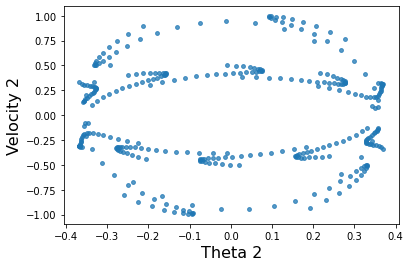

Execution time: 173.67290997505188 seconds


In [14]:
#Big mass ratio

start_time = time.time()


t1 = 300

theta1_0 = 0.25
theta2_0 = 0

m1=1
m2=1

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.show()

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

## 0.60 Radiens

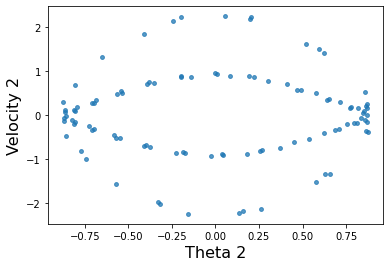

Execution time: 56.00134205818176 seconds


In [13]:
start_time = time.time()


t1 = 300

theta1_0 = 0.60
theta2_0 = 0

m1=1
m2=1

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} seconds")

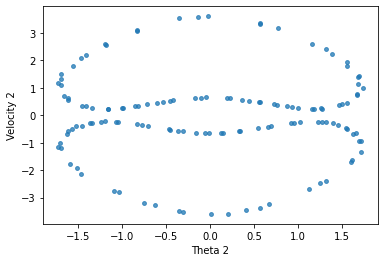

Execution time: 111.09937620162964 seconds


In [9]:
#Big mass ratio

start_time = time.time()


t1 = 100

theta1_0 = 0.60
theta2_0 = 0

m1=10
m2=1

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} seconds")

## 0.40 Radiens 

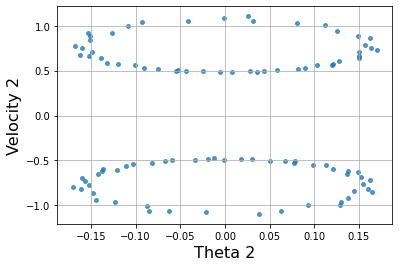

Execution time: 2.711926519870758 minutes


In [36]:
#Big mass ratio

start_time = time.time()


t1 = 200

theta1_0 = 0.40
theta2_0 = 0.40

m1=1
m2=1

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

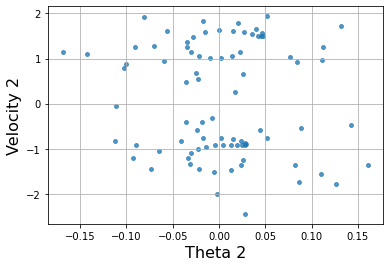

Execution time: 2.726810125509898 minutes


In [37]:
start_time = time.time()


t1 = 200

theta1_0 = 0.90
theta2_0 = 0.90

m1=1
m2=20

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

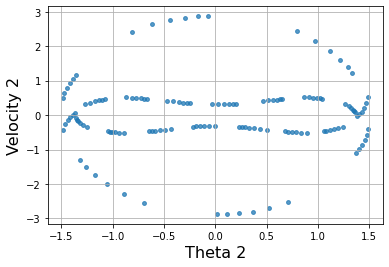

Execution time: 2.926424777507782 minutes


In [40]:
start_time = time.time()


t1 = 200

theta1_0 = 0.30
theta2_0 = 0.30

m2=1
m1=20

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

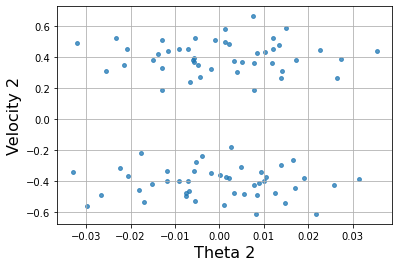

Execution time: 2.860317349433899 minutes


In [41]:
start_time = time.time()


t1 = 200

theta1_0 = 0.30
theta2_0 = 0.30

m1=1
m2=20

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

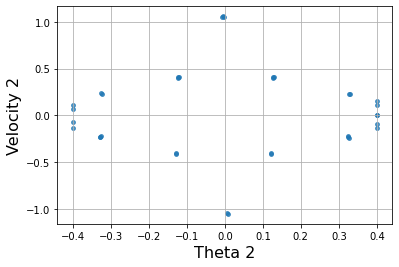

Execution time: 0.4169030507405599 seconds


In [18]:
start_time = time.time()


t1 = 30

theta1_0 = 0
theta2_0 = 0.40

m1=1
m2=1

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

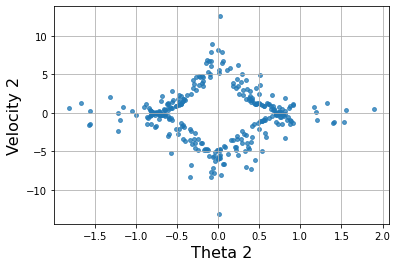

Execution time: 253.70924758911133 seconds


In [6]:
start_time = time.time()


t1 = 300

theta1_0 = 0
theta2_0 = 0.70

m1=1
m2=25

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

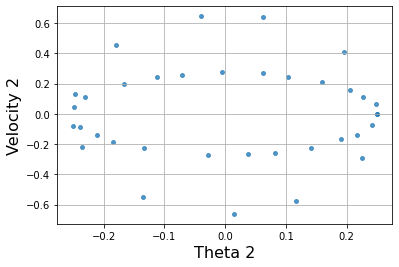

Execution time: 25.063294172286987 seconds


In [15]:
start_time = time.time()


t1 = 30

theta1_0 = 0
theta2_0 = 0.25

m1=1
m2=1

M=m1+m2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4_Double(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.75,s=15)
#plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2",fontdict={'size': 16})
plt.ylabel("Velocity 2",fontdict={'size': 16})
plt.grid(True)
plt.show()

end_time = time.time()
print(f"Execution time: {(end_time - start_time)/60} minutes")

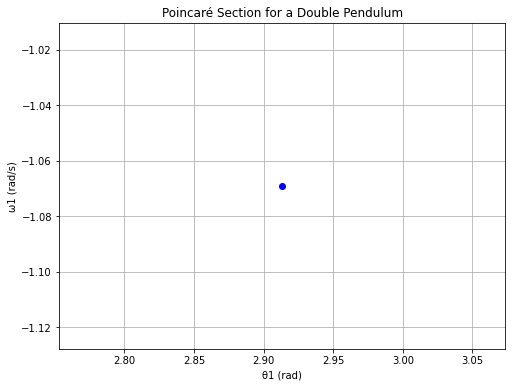

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants and initial conditions
g = 9.81  # Gravity (m/s^2)
L1 = L2 = 1.0  # Length of the pendulum arms (m)
m1 = m2 = 1.0  # Mass of the pendulum bobs (kg)
initial_angles = [np.pi / 4, np.pi / 2]  # Initial angles (radians)
initial_velocities = [0, 0]  # Initial angular velocities (rad/s)
T = 60  # Total time for the simulation (s)
dt = 0.01  # Time step for the simulation (s)
N = int(T / dt)  # Number of steps

# Equations of motion (simplified for small angles)
def equations(t, y):
    θ1, ω1, θ2, ω2 = y
    dθ1_dt = ω1
    dω1_dt = -(g/L1) * θ1 + (g/L2) * θ2
    dθ2_dt = ω2
    dω2_dt = -(g/L2) * θ2 + (g/L1) * θ1
    return [dθ1_dt, dω1_dt, dθ2_dt, dω2_dt]

# Initial state
initial_state = [*initial_angles, *initial_velocities]

# Solve the system
t_span = [0, T]
t_eval = np.linspace(0, T, N)
sol = solve_ivp(equations, t_span, initial_state, t_eval=t_eval, method='RK45')

# Extracting angles and velocities
θ1, ω1, θ2, ω2 = sol.y

# Recording Poincaré section: we choose moments when the second pendulum passes through the downward vertical
# This is when θ2 crosses multiples of 2π (or close to it, due to discretization)
indices = np.where(np.diff(np.sign(θ2 - np.pi)))[0]  # Crossing points

# Poincaré points
poincare_θ1 = θ1[indices]
poincare_ω1 = ω1[indices]

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(poincare_θ1, poincare_ω1, color='blue', marker='o')
plt.title('Poincaré Section for a Double Pendulum')
plt.xlabel('θ1 (rad)')
plt.ylabel('ω1 (rad/s)')
plt.grid(True)
plt.show()